In [1]:
import numpy as np
import flopy 
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import json
import os

c:\Users\lima0055\anaconda3\envs\gmdsitut\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
model_ws = 'C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK\\prt_simulation'
model_name='tracer_sim' 
prt_name = f"{model_name}-prt"
trackcsvfile_prt = f"{prt_name}.trk.csv"

In [3]:
sim = flopy.mf6.MFSimulation.load(sim_ws=model_ws)
gwf = sim.get_model()
prt = sim.get_model()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package npf...
    loading package sto...
    loading package oc...
    loading package ic...
    loading package chd...
  loading model prt6...
    loading package dis...
    loading package mip...
    loading package prp...
    loading package oc...
  loading exchange package gwf-prt_exg_0...
  loading solution package tracer_sim-gwf...
  loading solution package tracer_sim-prt...


In [4]:
pathlines = pd.read_csv(os.path.join(model_ws , trackcsvfile_prt))
len(pathlines)

1391901

In [5]:
pathlines.head()

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
0,1,1,2,1,1,2,199996,0,1,0,14.0,14.000000,6803.518460,6888.518460,-4.572000,NaN
1,2,1,2,1,1,2,199996,0,1,1,14.0,14.000002,6803.515003,6888.513460,-4.571993,NaN
2,2,1,2,1,1,2,200384,0,1,1,14.0,14.000005,6803.513460,6888.504032,-4.571990,NaN
3,2,1,2,1,1,2,200383,0,1,1,14.0,14.001093,6803.023310,6887.513460,-4.571579,NaN
4,2,1,2,1,1,2,200771,0,1,1,14.0,14.002281,6802.839004,6886.513460,-4.571856,NaN


In [76]:
#because flopy does not load budget file when we laod a simulation
from flopy.utils import CellBudgetFile

In [78]:
cbb = CellBudgetFile(os.path.join(model_ws, f"{model_name}-gwf.cbb"))

In [79]:
cbb.get_unique_record_names()

[np.bytes_(b'          STO-SS'),
 np.bytes_(b'          STO-SY'),
 np.bytes_(b'    FLOW-JA-FACE'),
 np.bytes_(b'      DATA-SPDIS'),
 np.bytes_(b'        DATA-SAT'),
 np.bytes_(b'             CHD')]

lets use DATA-SPDIS which is the darcy velocity (specific discharge)

In [164]:
spdis = cbb.get_data(text="DATA-SPDIS")[0]

In [110]:
len(cbb.get_data(text="DATA-SPDIS"))

20

In [6]:
import re

with open(os.path.join(model_ws, f"{prt_name}.mip"), "r") as f:
    content = f.read()
    # Searches for 'porosity' followed by 'constant' and then the number
    match = re.search(r"porosity\s+CONSTANT\s+([0-9.]+)", content, re.IGNORECASE)
    
    if match:
        porosity = float(match.group(1))
        print(f"porosity read from mip file (a PRT file): {porosity}")

porosity read from mip file (a PRT file): 4.457368


In [165]:
vx = spdis["qx"] / porosity
vy = spdis["qy"] / porosity
vz = spdis["qz"] / porosity

In [103]:
#working with only one particle
p_id = 1
p = pathlines[pathlines["irpt"] == p_id].copy()

In [87]:
len(p)

137

In [104]:
#computing distance between points
coords = p[["x", "y", "z"]].values
icell = p["icell"].values
dist = np.linalg.norm(coords[1:] - coords[:-1], axis=1)

In [411]:
len(dist)

136

In [90]:
cum_dist = np.cumsum(dist)
cum_dist

array([6.07908142e-03, 1.56328861e-02, 1.12083836e+00, 2.13768096e+00,
       3.14043254e+00, 4.14043420e+00, 5.14235304e+00, 6.14826049e+00,
       7.15815110e+00, 8.17228221e+00, 9.19087457e+00, 9.55379821e+00,
       1.02112198e+01, 1.12331089e+01, 1.22566962e+01, 1.32806078e+01,
       1.43036287e+01, 1.43306554e+01, 1.53220486e+01, 1.63373105e+01,
       1.73492628e+01, 1.83590124e+01, 1.93672627e+01, 2.03747451e+01,
       2.11122161e+01, 2.13821349e+01, 2.23893906e+01, 2.33980152e+01,
       2.44090015e+01, 2.54236574e+01, 2.64436997e+01, 2.72917934e+01,
       2.74706092e+01, 2.85014158e+01, 2.95427690e+01, 3.05967908e+01,
       3.08591222e+01, 3.16535222e+01, 3.27148344e+01, 3.37769181e+01,
       3.38851946e+01, 3.48219845e+01, 3.58554251e+01, 3.68784741e+01,
       3.78951453e+01, 3.83204760e+01, 3.89080150e+01, 3.99202442e+01,
       4.09340316e+01, 4.19501191e+01, 4.29694879e+01, 4.39942635e+01,
       4.40715550e+01, 4.42897694e+01, 4.52057402e+01, 4.63999462e+01,
      

In [7]:
import matplotlib.pyplot as plt

Text(0.5, 0, 'Time elapsed (T)')

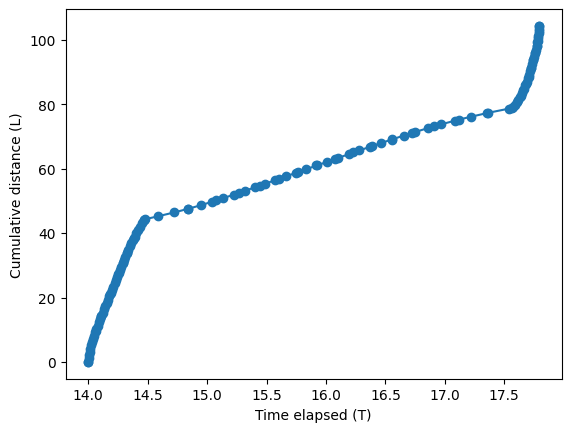

In [92]:
plt.plot(p["t"].values[1:], cum_dist)
plt.scatter(p["t"].values[1:], cum_dist)
plt.ylabel("Cumulative distance (L)")
plt.xlabel("Time elapsed (T)")

In [166]:
comp_dist = []
for row in range(len(p)-1):
    #k, i, j = gwf.modelgrid.get_lrc(int(icell[i]))[0]
    x_i1 = (vx[int(icell[row+1])-1]) * (p['t'].values[row+1] - p['t'].values[row]) + p['x'].values[row] 
    y_i1 = (vy[int(icell[row+1])-1]) * (p['t'].values[row+1] - p['t'].values[row]) + p['y'].values[row] 
    z_i1 = (vz[int(icell[row+1])-1]) * (p['t'].values[row+1] - p['t'].values[row]) + p['z'].values[row] 
    new_coords = np.array([x_i1, y_i1, z_i1])
    comp_dist.append(np.linalg.norm(new_coords - coords[row], axis=0))
    
comp_cum_dist = np.cumsum(comp_dist)

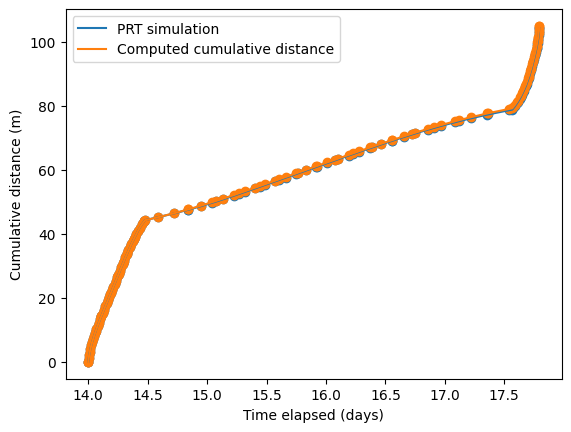

In [169]:
plt.plot(p["t"].values[1:], cum_dist, label="PRT simulation")
plt.scatter(p["t"].values[1:], cum_dist)
plt.plot(p["t"].values[1:], comp_cum_dist, label="Computed cumulative distance")
plt.scatter(p["t"].values[1:], comp_cum_dist)
plt.ylabel("Cumulative distance (m)")
plt.xlabel("Time elapsed (days)")
plt.legend()

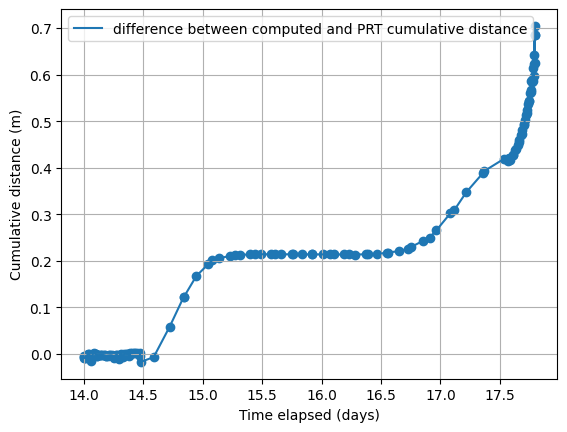

In [170]:
plt.plot(p["t"].values[1:], comp_cum_dist - cum_dist, label="difference between computed and PRT cumulative distance")
plt.scatter(p["t"].values[1:], comp_cum_dist - cum_dist)
plt.grid()
plt.ylabel("Cumulative distance (m)")
plt.xlabel("Time elapsed (days)")
plt.legend()

here on

In [19]:
print(f"this is the av. maximum linear velocity: {465/(porosity*1.0e-4)}")

this is the av. maximum linear velocity: 1043216.5349596443


to define x1

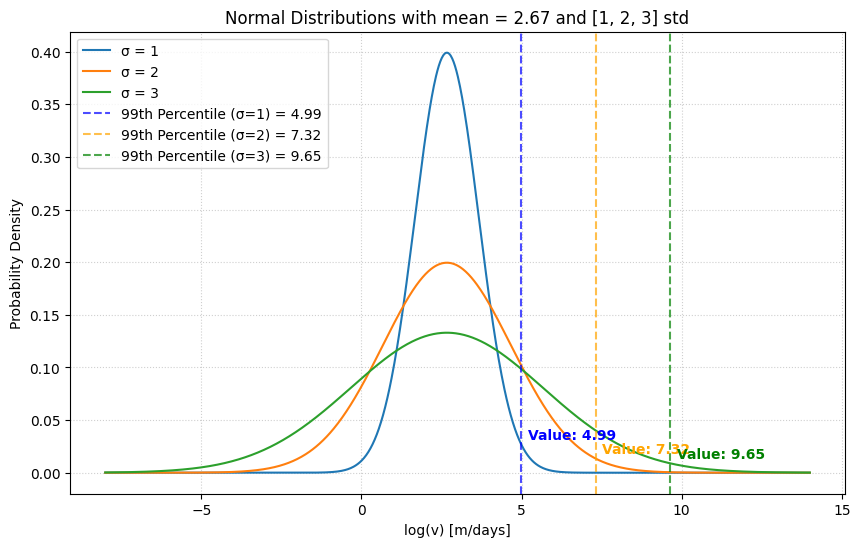

In [714]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Define parameters
mean = np.log10(465) #log of the average maximum linear velocity, which is the distance between the injection point and the well (95 m) divided by the time (0.2) 
sigmas = [1, 2, 3]
x_ = np.linspace(-8, 14, 1000)

plt.figure(figsize=(10, 6))

# 2. Plot the three lines
for s in sigmas:
    y = norm.pdf(x_, mean, s)
    plt.plot(x_, y, label=f'σ = {s}')

# 3. Calculate and plot the 95th percentile for σ's
sigmas = [1, 2, 3]
colors = ['blue', 'orange', 'green']
for s in sigmas:
    p95_value = norm.ppf(0.99, loc=mean, scale=s)
    p95_pdf_height = norm.pdf(p95_value, loc=mean, scale=s)

    # Add the vertical line
    plt.axvline(p95_value, color=colors[sigmas.index(s)], linestyle='--', alpha=0.7, label='99th Percentile (σ={}) = {p95_value:.2f}'.format(s, p95_value=p95_value))

    # Add a text label for the value
    plt.text(p95_value + 0.2, p95_pdf_height + 0.005, f'Value: {p95_value:.2f}', 
            color=colors[sigmas.index(s)], fontweight='bold')

# 4. Final touches
plt.title('Normal Distributions with mean = {:.2f} and [1, 2, 3] std'.format(mean))
plt.xlabel('log(v) [m/days]')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


In [829]:
print(f"PRT log(v) range: ({np.log10(np.nanmin(pathlines_ctrw[pathlines_ctrw['v_prt'] > 0]['v_prt']))}, {np.log10(np.nanmax(pathlines_ctrw[pathlines_ctrw['v_prt'] > 0]['v_prt']))})")
print(f"PRT linear velocity range: ({np.nanmin(pathlines_ctrw[pathlines_ctrw['v_prt'] > 0]['v_prt'])}, {np.nanmax(pathlines_ctrw[pathlines_ctrw['v_prt'] > 0]['v_prt'])})")

PRT log(v) range: (0.886752501216924, 3.8397800963919053)
PRT linear velocity range: (7.704642663524914, 6914.807532147831)


In [36]:
import numpy as np

m = 800
log_m = np.log10(m)
alpha = -0.1

a = 100.0

#x1 = 10**4.99 #values computed from field BTC and darcy velocity
x1 = m*a #x1 defined as a function of m.
log_x1 = np.log10(x1)

#print(f"for alpha={alpha}, and x1={x1}, the valid m range is: ({log_x1*2**(-(1/(alpha+1)))}, {log_x1})")
log_lb = log_x1*2**(-(1/(alpha+1)))
log_ub = log_x1
print(f"or in linear space, the valid m range is: ({10**log_lb}, {10**log_ub})")
print(f"you insert m={m}, and x1={x1}, and alpha={alpha}")
print("================================")



if ((log_x1*2**(-(1/(alpha+1)))) < log_m ) and (log_m < log_x1):
    x0 = (2*log_m**(alpha+1) - log_x1**(alpha+1))**(1/(alpha+1))
    #x1 = 1

    #np.random.seed(123)
    y = np.random.uniform(size=100000)

    

    log_x = (((log_x1**(alpha+1) - x0**(alpha+1)) * y) + x0**(alpha+1)) ** (1/(alpha+1))
    x = 10**log_x

    summary = {
        "Min": np.min(x),
        #"1st Qu.": np.percentile(x, 25),
        "Median": np.median(x),
        "Mean": 10**np.mean(np.log10(x)),
        #"3rd Qu.": np.percentile(x, 75),
        "Max": np.max(x)
    }

    print(f'Min = {summary["Min"]}')
    print(f'Median = {summary["Median"]}')
    print(f'Mean = {summary["Mean"]}')
    print(f'Max = {summary["Max"]}')
    min = summary["Min"]
    mean = summary["Mean"]
    median = summary["Median"]
    max = summary["Max"]


or in linear space, the valid m range is: (186.13305930175187, 80000.00000000003)
you insert m=800, and x1=80000.0, and alpha=-0.1
Min = 10.992525148056881
Median = 796.6434824338528
Mean = 835.144087887602
Max = 79987.22304421732


In [28]:
#MEAN CHECK
import numpy as np
from scipy.optimize import brentq

m     = 6700
log_m = np.log10(m)        # target mean in log10 space
alpha = -0.75
a     = 2.0

x1      = m * a
log_x1  = np.log10(x1)

p = alpha + 1              # shorthand: exponent in CDF
q = alpha + 2              # shorthand: exponent in mean integral

# ── validity check ────────────────────────────────────────────────────────────
# Mean of the TPL is bounded: it must lie strictly inside (x0_min, x1)
# The minimum possible mean is when x0 → 0, giving E[X] → x1*(p/q)
mean_min = log_x1 * (p / q)   # lower bound on achievable mean
mean_max = log_x1              # upper bound: mean can never exceed x1

print(f"Valid mean range (log10 space): ({mean_min:.4f}, {mean_max:.4f})")
print(f"Valid mean range (linear space): ({10**mean_min:.4f}, {10**mean_max:.4f})")
print(f"You inserted m={m}, x1={x1}, alpha={alpha}")
print("================================")

if mean_min < log_m < mean_max:

    # ── solve for x0 numerically ──────────────────────────────────────────────
    # From Step 3 of derivation:
    # g(x0) = p*(x1^q - x0^q) - log_m*q*(x1^p - x0^p) = 0
    def mean_eq(x0):
        return p * (log_x1**q - x0**q) - q * log_m * (log_x1**p - x0**p)

    eps   = 1e-10
    x0    = brentq(mean_eq, eps, log_x1 - eps)

    # ── sample via inverse CDF ────────────────────────────────────────────────
    y     = np.random.uniform(size=10000000)
    log_x = ((log_x1**p - x0**p) * y + x0**p) ** (1 / p)
    x     = 10**log_x

    # ── summary ───────────────────────────────────────────────────────────────
    mean = 10**np.mean(np.log10(x))   
    median = np.median(x)
    print(f"x0 (log10 space) = {x0:.6f}  →  x0 (linear) = {10**x0:.4f}")
    print(f'Min    = {np.min(x):.4f}')
    print(f'Median = {np.median(x):.4f}')
    print(f'Mean   = {10**np.mean(np.log10(x)):.4f}')   # geometric mean in linear = arithmetic mean in log space
    print(f'Max    = {np.max(x):.4f}')

else:
    print(f"m={m} is outside the valid mean range.")
    print(f"Choose m between {10**mean_min:.4f} and {10**mean_max:.4f}")

Valid mean range (log10 space): (0.8254, 4.1271)
Valid mean range (linear space): (6.6899, 13400.0000)
You inserted m=6700, x1=13400.0, alpha=-0.75
x0 (log10 space) = 3.536444  →  x0 (linear) = 3439.0918
Min    = 3439.0926
Median = 6656.8177
Mean   = 6700.7298
Max    = 13399.9981


(1)

Grid velocity range: [7.7046, 6914.8075]
Grid velocity median: 209.9743
In log space: [0.8868, 3.8398]

Valid (alpha, x1) combinations found: 40
 alpha    x1_linear  x1_          lb_  ub_  lb_linear  covers_v_min  covers_v_max  median_inside    lb_margin
 -0.99 97723.722096 4.99 3.936416e-30 4.99   1.000000          True          True           True 5.065737e+07
 -0.98 97723.722096 4.99 4.432010e-15 4.99   1.000000          True          True           True 5.065737e+07
 -0.97 97723.722096 4.99 4.610705e-10 4.99   1.000000          True          True           True 5.065737e+07
 -0.96 97723.722096 4.99 1.487136e-07 4.99   1.000000          True          True           True 5.065737e+07
 -0.95 97723.722096 4.99 4.758835e-06 4.99   1.000011          True          True           True 5.065737e+07
 -0.94 97723.722096 4.99 4.796605e-05 4.99   1.000110          True          True           True 5.065737e+07
 -0.93 97723.722096 4.99 2.498458e-04 4.99   1.000575          True          True    

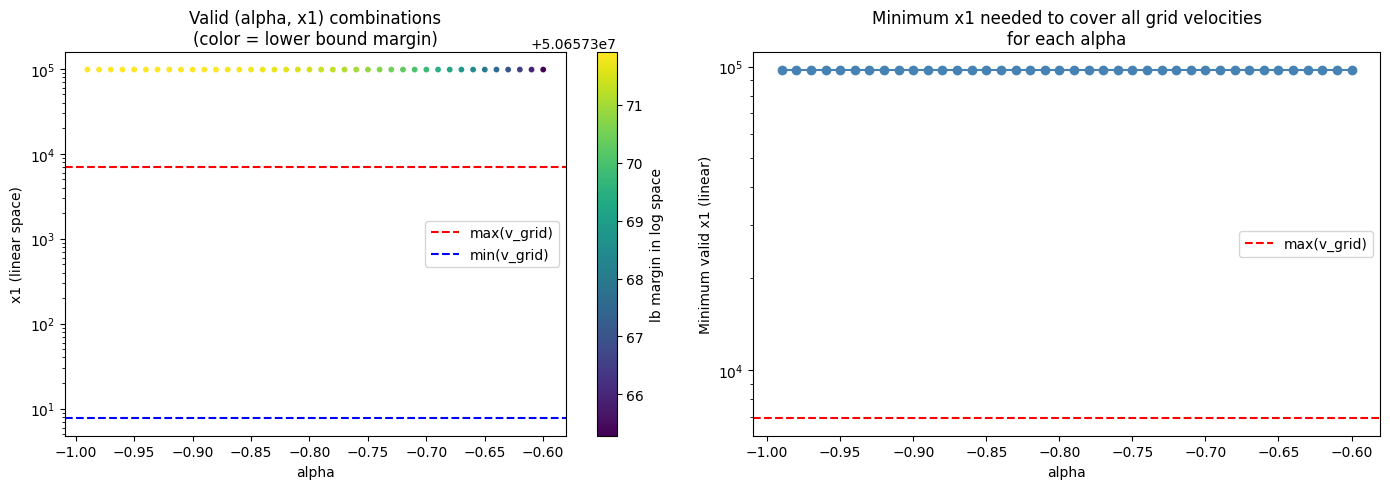

In [679]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Extract velocity range from particle tracking ---
v_values = pathlines_ctrw['v_prt'].values
v_values = v_values[v_values > 0]  # remove zeros if any

v_min_grid = np.min(v_values)
v_max_grid = np.max(v_values)
v_median_grid = np.median(v_values)

print(f"Grid velocity range: [{v_min_grid:.4f}, {v_max_grid:.4f}]")
print(f"Grid velocity median: {v_median_grid:.4f}")
print(f"In log space: [{np.log10(v_min_grid):.4f}, {np.log10(v_max_grid):.4f}]")
print("=" * 60)

# --- Define search grids ---
# x1 in LINEAR space (will be converted to log inside)
# Search x1 from max(v_grid) up to some multiple of it
alpha_values = np.arange(-0.99, -0.1, 0.01)          # alpha range to explore
'''x1_linear_values = np.logspace(                       # x1 in linear space
    np.log10(v_max_grid),                             # minimum: must cover max v
    np.log10(x1),                      # 
    200
)'''

x1_linear_values = [x1]

# --- Storage ---
results = []

for alpha_ in alpha_values:
    for x1_lin in x1_linear_values:
        x1_ = np.log10(x1_lin)  # convert to log space as in your original code

        # Valid m range in log space
        lb_ = x1_ * 2 ** (-(1 / (alpha_ + 1)))
        ub_ = x1_

        # Check if the range covers ALL grid cell velocities
        covers_min = lb_ <= np.log10(v_min_grid)
        covers_max = ub_ >= np.log10(v_max_grid)

        if covers_min and covers_max:
            # Also verify median is inside (sanity check)
            m_median = np.log10(v_median_grid)
            median_inside = lb_ < m_median < ub_

            results.append({
                'alpha': alpha_,
                'x1_linear': x1_lin,
                'x1_': x1_,
                'lb_': lb_,
                'ub_': ub_,
                'lb_linear': 10**lb_,
                'covers_v_min': covers_min,
                'covers_v_max': covers_max,
                'median_inside': median_inside,
                # How much margin is there at the lower end
                'lb_margin': 10**v_min_grid - 10**lb_,
            })

df = pd.DataFrame(results)
print(f"\nValid (alpha, x1) combinations found: {len(df)}")
print(df.head(100).to_string(index=False))

if len(df) > 1:
    # --- Plot: which combinations are valid ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: scatter of valid combinations colored by lb_margin
    sc = axes[0].scatter(df['alpha'], df['x1_linear'],
                        c=df['lb_margin'], cmap='viridis', s=10)
    axes[0].set_xlabel('alpha')
    axes[0].set_ylabel('x1 (linear space)')
    axes[0].set_yscale('log')
    axes[0].set_title('Valid (alpha, x1) combinations\n(color = lower bound margin)')
    axes[0].axhline(v_max_grid, color='red', linestyle='--', label='max(v_grid)')
    axes[0].axhline(v_min_grid, color='blue', linestyle='--', label='min(v_grid)')
    axes[0].legend()
    plt.colorbar(sc, ax=axes[0], label='lb margin in log space')

    # Panel 2: for each alpha, what is the minimum valid x1?
    min_x1_per_alpha = df.groupby('alpha')['x1_linear'].min().reset_index()
    axes[1].plot(min_x1_per_alpha['alpha'], min_x1_per_alpha['x1_linear'],
                'o-', color='steelblue')
    axes[1].axhline(v_max_grid, color='red', linestyle='--', label='max(v_grid)')
    axes[1].set_xlabel('alpha')
    axes[1].set_ylabel('Minimum valid x1 (linear)')
    axes[1].set_yscale('log')
    axes[1].set_title('Minimum x1 needed to cover all grid velocities\nfor each alpha')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('alpha_x1_valid_combinations.png', dpi=150)
    plt.show()

    

In [ ]:
x1

16.0

In [834]:
alpha

-0.1

Text(0.5, 1.0, '100000 sampled from a uniform distribution')

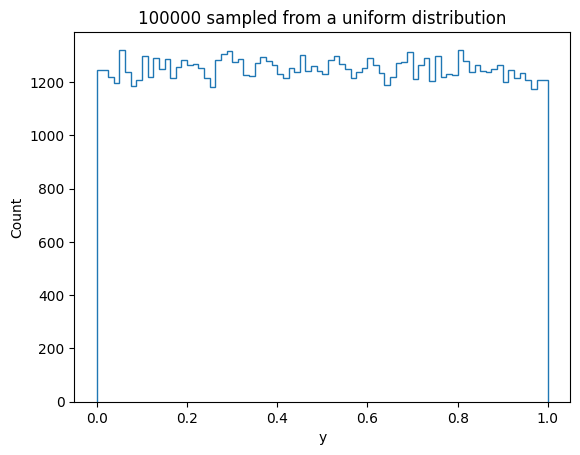

In [835]:
plt.hist(y, bins=80, density=False, histtype='step', label="Uniform samples")
plt.xlabel("y")
plt.ylabel("Count")
plt.title("100000 sampled from a uniform distribution")

Text(0.5, 1.0, 'CDF of TPL with alpha=-0.75, m=6700, and x1=13400.00 derived using x1=2.0m')

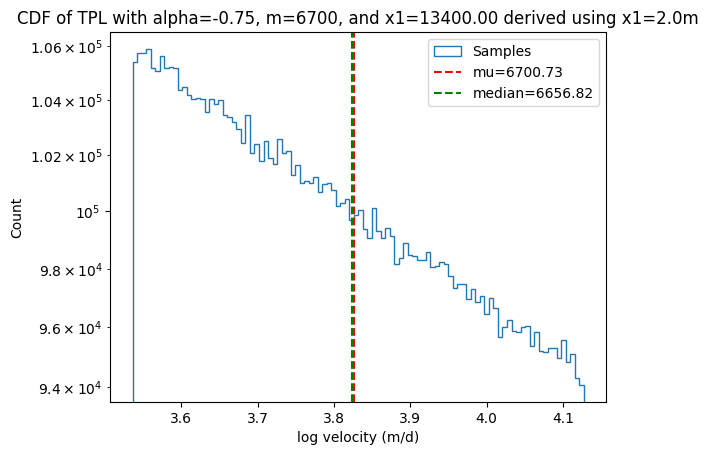

In [30]:
#log_bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 100)
plt.hist(np.log10(x), bins=100, density=False, histtype='step', label="Samples")
#plt.xlim(x0*0.9, x1*1.05)
plt.axvline(np.log10(mean), color='red', linestyle='--', label=f"mu={mean:.2f}")
plt.axvline(np.log10(median), color='green', linestyle='--', label=f"median={median:.2f}")
plt.legend()
plt.xlabel("log velocity (m/d)")
plt.ylabel("Count") 
plt.yscale('log')
plt.title(f"CDF of TPL with alpha={alpha}, m={m}, and x1={x1:.2f} derived using x1={a}m")

In [ ]:
def sample_tpl(alpha, x1, m):
    #return ctrw linear velocity

    x1 = m*2.0

    m = np.log10(m)
    x1 = np.log10(x1)
    
    x0 = (2*m**(alpha+1) - x1**(alpha+1))**(1/(alpha+1))

    #np.random.seed(123)
    y = np.random.uniform(size=1)

    x = ((x1**(alpha+1) - x0**(alpha+1)) * y + x0**(alpha+1)) ** (1/(alpha+1))
    return 10**x

In [811]:
alpha

-0.1

In [813]:
p_ctrw = pathlines.copy()

#alpha = -0.99
#log_x1 = np.log10(x1)

pathlines_ctrw = pd.DataFrame() #empty dataframe to store the CTRW pathlines

for p in pathlines['irpt'].unique():
    if p % 10 == 0:
        p_ctrw = pathlines[pathlines["irpt"] == p].copy()

        p_ctrw['p_index'] = range(0, len(p_ctrw))
        for i in range(len(p_ctrw)-1):
            if i == 0: 
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_S'] = 0
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_prt'] = 0
                p_ctrw.loc[p_ctrw['p_index'] == i, 'v_prt'] = 0
                p_ctrw.loc[p_ctrw['p_index'] == i, 'v_ctrw'] = 0
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_ctrw'] = 0
                p_ctrw.loc[p_ctrw['p_index'] == i, 't_ctrw'] = p_ctrw.loc[p_ctrw['p_index'] == i, 't'].values

                #m*2 velocities
                p_ctrw.loc[p_ctrw['p_index'] == i, 'v_prtx2'] = 0
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_prtx2'] = 0
                p_ctrw.loc[p_ctrw['p_index'] == i, 't_prtx2'] = p_ctrw.loc[p_ctrw['p_index'] == i, 't'].values
            else:
                #computing delta_S
                coords_i_minus_1 = p_ctrw.loc[p_ctrw['p_index'] == i-1, ["x", "y", "z"]].values
                coords_i = p_ctrw.loc[p_ctrw['p_index'] == i, ["x", "y", "z"]].values
                dist_i = np.linalg.norm(coords_i - coords_i_minus_1)
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_S'] = dist_i
                
                #delta_t_prt
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_prt'] = p_ctrw.loc[p_ctrw['p_index'] == i, 't'].values - p_ctrw.loc[p_ctrw['p_index'] == i-1, 't'].values
                
                #v_prt
                p_ctrw.loc[p_ctrw['p_index'] == i, 'v_prt'] = p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_S'].values / p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_prt'].values
                
                #getting v_prt (i.e. m) to sample v_ctrw
                m = p_ctrw.loc[p_ctrw['p_index'] == i, 'v_prt'].values
                #log_m = np.log10(m)
                v_ctrw_sample =sample_tpl(alpha, x1, m) #CHANGE MEDIAN OR MEAN
                p_ctrw.loc[p_ctrw['p_index'] == i, 'v_ctrw'] = v_ctrw_sample
                p_ctrw.loc[p_ctrw['p_index'] == i, 'v_prtx2'] = m*2

                #delta_t_ctrw
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_ctrw'] = p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_S'].values / p_ctrw.loc[p_ctrw['p_index'] == i, 'v_ctrw'].values
                
                #delta_t_2*PRT_v
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_prtx2'] = p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_S'].values / p_ctrw.loc[p_ctrw['p_index'] == i, 'v_prtx2'].values

                #t_ctrw
                p_ctrw.loc[p_ctrw['p_index'] == i, 't_ctrw'] = p_ctrw.loc[p_ctrw['p_index'] == i-1, 't_ctrw'].values + p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_ctrw'].values

                #t_prtx2
                p_ctrw.loc[p_ctrw['p_index'] == i, 't_prtx2'] = p_ctrw.loc[p_ctrw['p_index'] == i-1, 't_prtx2'].values + p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_prtx2'].values
        pathlines_ctrw = pd.concat([pathlines_ctrw, p_ctrw], ignore_index=True)
    else: 
        continue

In [814]:
pathlines_ctrw.head()

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,...,p_index,delta_S,delta_t_prt,v_prt,v_ctrw,delta_t_ctrw,t_ctrw,v_prtx2,delta_t_prtx2,t_prtx2
0,1,1,2,1,10,2,199996,0,1,0,...,0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,14.000000,0.000000,0.000000e+00,14.000000
1,2,1,2,1,10,2,199996,0,1,1,...,1,0.005703,0.000002,3150.022778,249882.597806,2.282325e-08,14.000000,6300.045555,9.052528e-07,14.000001
2,2,1,2,1,10,2,200384,0,1,1,...,2,0.570573,0.000236,2413.650883,252821.691488,2.256821e-06,14.000002,4827.301765,1.181971e-04,14.000119
3,2,1,2,1,10,2,200383,0,1,1,...,3,0.487781,0.000480,1017.261588,29058.818323,1.678600e-05,14.000019,2034.523177,2.397522e-04,14.000359
4,2,1,2,1,10,2,200771,0,1,1,...,4,1.009440,0.001188,849.783430,49073.974600,2.056975e-05,14.000040,1699.566859,5.939393e-04,14.000953


In [815]:
pathlines_ctrw.describe()

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,...,p_index,delta_S,delta_t_prt,v_prt,v_ctrw,delta_t_ctrw,t_ctrw,v_prtx2,delta_t_prtx2,t_prtx2
count,138865.000000,138865.0,138865.0,138865.0,138865.000000,138865.000000,138865.000000,138865.0,138865.000000,138865.000000,...,138865.000000,137865.000000,137865.000000,137865.000000,1.378650e+05,137865.000000,137865.000000,137865.000000,137865.000000,137865.000000
mean,1.992799,1.0,2.0,1.0,5072.241386,2.342030,268907.472488,0.0,1.028805,1.007201,...,69.056090,0.749411,0.009283,313.928086,1.683042e+04,0.012474,14.557293,627.856173,0.004642,14.261684
std,0.084554,0.0,0.0,0.0,2895.330200,0.474391,75161.105482,0.0,0.338217,0.189617,...,40.313233,0.378003,0.012645,446.345359,4.705333e+04,0.085728,1.144796,892.690717,0.006323,0.250721
min,1.000000,1.0,2.0,1.0,10.000000,2.000000,197280.000000,0.0,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,14.000000,0.000000,0.000000,14.000000
25%,2.000000,1.0,2.0,1.0,2560.000000,2.000000,208932.000000,0.0,1.000000,1.000000,...,34.000000,0.420803,0.001649,41.531011,1.592761e+02,0.000038,14.002051,83.062022,0.000825,14.031461
50%,2.000000,1.0,2.0,1.0,5110.000000,2.000000,228743.000000,0.0,1.000000,1.000000,...,69.000000,0.880010,0.003057,207.076214,4.364862e+03,0.000151,14.175476,414.152428,0.001529,14.179379
75%,2.000000,1.0,2.0,1.0,7600.000000,3.000000,369577.000000,0.0,1.000000,1.000000,...,104.000000,1.044698,0.012185,454.792913,1.659475e+04,0.003207,14.649706,909.585827,0.006092,14.508526
max,2.000000,1.0,2.0,1.0,10000.000000,3.000000,380044.000000,0.0,5.000000,3.000000,...,168.000000,1.538231,0.130610,6914.807532,1.428294e+06,8.982068,33.885663,13829.615064,0.065305,15.143579


In [687]:
lb

np.float64(1.491538449096026)

C:\Users\lima0055\AppData\Local\Temp\ipykernel_37672\4091333908.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


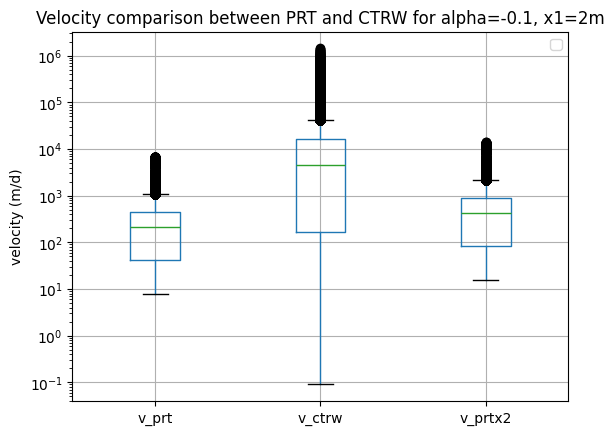

In [816]:
ub = x1
lb = 10**log_lb


pathlines_ctrw.query("v_prt != 0 and v_ctrw != 0").boxplot(column=['v_prt', 'v_ctrw', 'v_prtx2'])
#plt.hlines(ub, 0, 3, colors='red', linestyles='dashed', label=f"x1={x1}")
#plt.hlines(lb, 0, 3, colors='blue', linestyles='dashed', label=f"lb={lb}")
plt.title(f'Velocity comparison between PRT and CTRW for alpha={alpha}, x1=2m')
plt.ylabel('velocity (m/d)')
plt.yscale('log')
plt.legend()
plt.show()

In [817]:
alpha

-0.1

In [818]:
pathlines_ctrw.to_csv(os.path.join(model_ws, f"{prt_name}_ctrw_pathlines_median_x1=2m_alpha-01.csv"), index=False)

checkpoint

In [195]:
pathlines_ctrw = pd.read_csv(os.path.join(model_ws, f"{prt_name}_ctrw_pathlines_median_fieldx1_alpha-065.csv"))

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK\\prt_simulation\\tracer_sim-prt_ctrw_pathlines_median_fieldx1_alpha-065.csv'

C:\Users\lima0055\AppData\Local\Temp\ipykernel_37672\2950244292.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


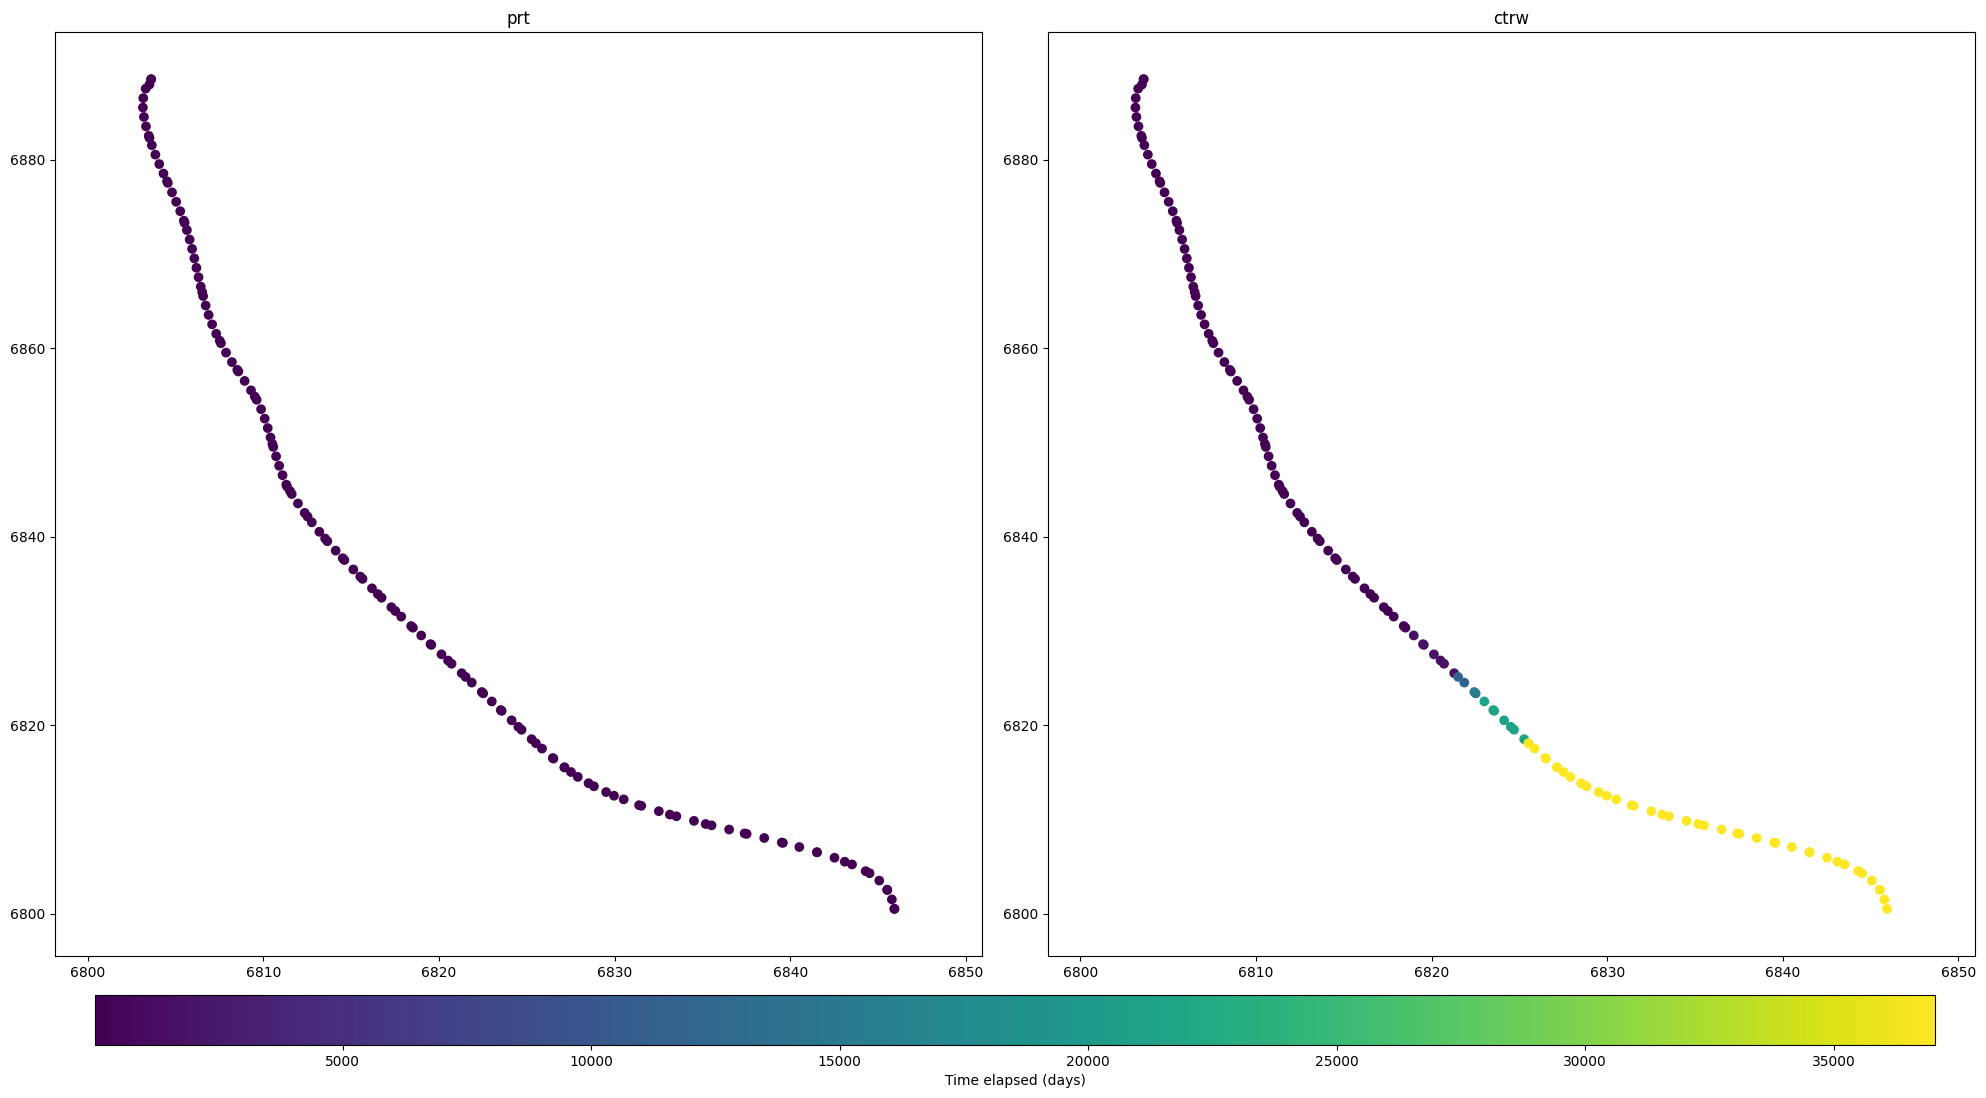

In [689]:
import matplotlib.pyplot as plt

import matplotlib.colors as colors
import flopy

p_ctrw = pathlines_ctrw[pathlines_ctrw["irpt"] == 10].copy() #plotting only one particle for now

fig = plt.figure(figsize=(20, 10)) # Increased width for two plots

t_combined = np.concatenate([p_ctrw["t"].values, p_ctrw["t_ctrw"].values])[:-1]
vmin, vmax = t_combined.min(), t_combined.max()

norm = colors.Normalize(vmin=vmin, vmax=vmax)

ax1 = fig.add_subplot(1, 2, 1)
modelmap1 = flopy.plot.PlotMapView(model=gwf, ax=ax1)
modelmap1.plot_grid()

sc1 = ax1.scatter(p_ctrw["x"], p_ctrw["y"], c=p_ctrw["t"], cmap="viridis", norm=norm)
#plt.colorbar(sc1, ax=ax1, label="Time elapsed (days)")

ax1.set_title("prt")
ax1.set_xlim(p_ctrw['x'].min() - 5, p_ctrw['x'].max() + 5)
ax1.set_ylim(p_ctrw['y'].min() - 5, p_ctrw['y'].max() + 5)

ax2 = fig.add_subplot(1, 2, 2)
modelmap2 = flopy.plot.PlotMapView(model=gwf, ax=ax2)
modelmap2.plot_grid()

sc2 = ax2.scatter(p_ctrw["x"], p_ctrw["y"], c=p_ctrw["t_ctrw"], cmap="viridis", norm=norm) 
#plt.colorbar(sc2, ax=[ax1, ax2], label="Time elapsed (days)", orientation='horizontal')
#cbar = fig.colorbar(sc1, ax=[ax1, ax2], orientation='horizontal', pad=0.1)


cbar_ax = fig.add_axes([0.05, -0.05, 0.92, 0.05]) 
cbar = fig.colorbar(sc1, ax=[ax1, ax2], orientation='horizontal', pad=0.1, cax=cbar_ax)
cbar.set_label("Time elapsed (days)")

ax2.set_title("ctrw")
ax2.set_xlim(p_ctrw['x'].min() - 5, p_ctrw['x'].max() + 5)
ax2.set_ylim(p_ctrw['y'].min() - 5, p_ctrw['y'].max() + 5)

plt.tight_layout()
plt.show()


(6820.0, 6850.0)

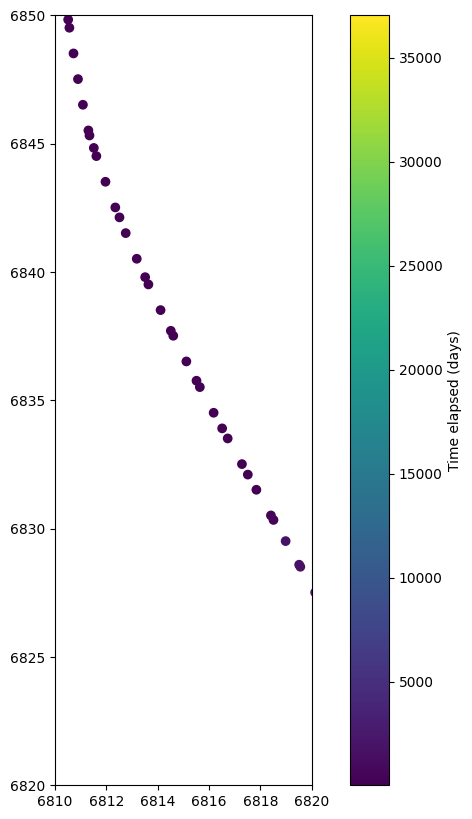

In [690]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, aspect="equal")
modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax)
plt.scatter(p_ctrw["x"].values, p_ctrw["y"].values, c=p_ctrw["t_ctrw"].values, cmap="viridis", label="Particle pathlines")
plt.colorbar(label="Time elapsed (days)")
#plt.xlim(p['x'].min()-5, p['x'].min()+5)
#plt.ylim(p['y'].max()-10, p['y'].max()+1)

modelmap.plot_grid()


#plt.xlim(6813, 6816)
#plt.ylim(6833, 6836)
plt.xlim(6810, 6820)
plt.ylim(6820, 6850)

In [819]:
#to add the ctrw time to the last point (hzwell)
for p in pathlines_ctrw['irpt'].unique():
    mask = pathlines_ctrw['irpt'] == p
    group_indices = pathlines_ctrw[mask].index

    if len(group_indices) >= 2:
        last_idx = group_indices[-1]
        second_last_idx = group_indices[-2]
        pathlines_ctrw.loc[last_idx, 't_ctrw'] = pathlines_ctrw.loc[second_last_idx, 't_ctrw']


pathlines_ctrw.loc[pathlines_ctrw['irpt'] == 10, :]

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,...,p_index,delta_S,delta_t_prt,v_prt,v_ctrw,delta_t_ctrw,t_ctrw,v_prtx2,delta_t_prtx2,t_prtx2
0,1,1,2,1,10,2,199996,0,1,0,...,0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,14.000000,0.000000,0.000000e+00,14.000000
1,2,1,2,1,10,2,199996,0,1,1,...,1,0.005703,0.000002,3150.022778,249882.597806,2.282325e-08,14.000000,6300.045555,9.052528e-07,14.000001
2,2,1,2,1,10,2,200384,0,1,1,...,2,0.570573,0.000236,2413.650883,252821.691488,2.256821e-06,14.000002,4827.301765,1.181971e-04,14.000119
3,2,1,2,1,10,2,200383,0,1,1,...,3,0.487781,0.000480,1017.261588,29058.818323,1.678600e-05,14.000019,2034.523177,2.397522e-04,14.000359
4,2,1,2,1,10,2,200771,0,1,1,...,4,1.009440,0.001188,849.783430,49073.974600,2.056975e-05,14.000040,1699.566859,5.939393e-04,14.000953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,2,1,2,1,10,2,233405,0,1,1,...,132,1.062108,0.001061,1000.816087,111183.684014,9.552736e-06,14.832667,2001.632174,5.306212e-04,14.525110
133,2,1,2,1,10,2,233406,0,1,1,...,133,0.039583,0.000030,1301.941747,98955.815353,4.000057e-07,14.832668,2603.883493,1.520148e-05,14.525126
134,2,1,2,1,10,2,233794,0,1,1,...,134,1.032563,0.000534,1935.043833,262374.158684,3.935459e-06,14.832672,3870.087666,2.668060e-04,14.525392
135,2,1,2,1,10,2,234182,0,1,1,...,135,1.010483,0.000230,4395.596009,584410.873151,1.729063e-06,14.832673,8791.192017,1.149427e-04,14.525507


In [820]:
#to add the 2*m time to the last point (hzwell)
for p in pathlines_ctrw['irpt'].unique():
    mask = pathlines_ctrw['irpt'] == p
    group_indices = pathlines_ctrw[mask].index

    if len(group_indices) >= 2:
        last_idx = group_indices[-1]
        second_last_idx = group_indices[-2]
        pathlines_ctrw.loc[last_idx, 't_prtx2'] = pathlines_ctrw.loc[second_last_idx, 't_prtx2']


pathlines_ctrw.loc[pathlines_ctrw['irpt'] == 10, :]

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,...,p_index,delta_S,delta_t_prt,v_prt,v_ctrw,delta_t_ctrw,t_ctrw,v_prtx2,delta_t_prtx2,t_prtx2
0,1,1,2,1,10,2,199996,0,1,0,...,0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,14.000000,0.000000,0.000000e+00,14.000000
1,2,1,2,1,10,2,199996,0,1,1,...,1,0.005703,0.000002,3150.022778,249882.597806,2.282325e-08,14.000000,6300.045555,9.052528e-07,14.000001
2,2,1,2,1,10,2,200384,0,1,1,...,2,0.570573,0.000236,2413.650883,252821.691488,2.256821e-06,14.000002,4827.301765,1.181971e-04,14.000119
3,2,1,2,1,10,2,200383,0,1,1,...,3,0.487781,0.000480,1017.261588,29058.818323,1.678600e-05,14.000019,2034.523177,2.397522e-04,14.000359
4,2,1,2,1,10,2,200771,0,1,1,...,4,1.009440,0.001188,849.783430,49073.974600,2.056975e-05,14.000040,1699.566859,5.939393e-04,14.000953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,2,1,2,1,10,2,233405,0,1,1,...,132,1.062108,0.001061,1000.816087,111183.684014,9.552736e-06,14.832667,2001.632174,5.306212e-04,14.525110
133,2,1,2,1,10,2,233406,0,1,1,...,133,0.039583,0.000030,1301.941747,98955.815353,4.000057e-07,14.832668,2603.883493,1.520148e-05,14.525126
134,2,1,2,1,10,2,233794,0,1,1,...,134,1.032563,0.000534,1935.043833,262374.158684,3.935459e-06,14.832672,3870.087666,2.668060e-04,14.525392
135,2,1,2,1,10,2,234182,0,1,1,...,135,1.010483,0.000230,4395.596009,584410.873151,1.729063e-06,14.832673,8791.192017,1.149427e-04,14.525507


In [821]:
termination_pts = pathlines_ctrw[pathlines_ctrw.ireason == 3].set_index('irpt')

termination_pts['elapsed_time_prt'] = termination_pts.t - termination_pts.trelease
termination_pts['elapsed_time_ctrw'] = termination_pts.t_ctrw - termination_pts.trelease
termination_pts['elapsed_time_prtx2'] = termination_pts.t_prtx2 - termination_pts.trelease
termination_pts.head()

,kper,kstp,imdl,iprp,ilay,icell,izone,istatus,ireason,trelease,...,v_prt,v_ctrw,delta_t_ctrw,t_ctrw,v_prtx2,delta_t_prtx2,t_prtx2,elapsed_time_prt,elapsed_time_ctrw,elapsed_time_prtx2
irpt,,,,,,,,,,,,,,,,,,,,,
10,2,1,2,1,2,234570,0,5,3,14.0,...,NaN,NaN,NaN,14.832673,NaN,NaN,14.525507,1.051015,0.832673,0.525507
20,2,1,2,1,2,234570,0,5,3,14.0,...,NaN,NaN,NaN,14.412594,NaN,NaN,14.524460,1.048921,0.412594,0.524460
30,2,1,2,1,2,234570,0,5,3,14.0,...,NaN,NaN,NaN,15.052012,NaN,NaN,14.526076,1.052152,1.052012,0.526076
40,2,1,2,1,2,234570,0,5,3,14.0,...,NaN,NaN,NaN,14.685693,NaN,NaN,14.529472,1.058944,0.685693,0.529472
50,2,1,2,1,2,234570,0,5,3,14.0,...,NaN,NaN,NaN,14.680593,NaN,NaN,14.535287,1.070575,0.680593,0.535287


In [822]:
len(termination_pts)

1000

In [823]:
termination_pts[['elapsed_time_prt', 'elapsed_time_ctrw']].describe()

,elapsed_time_prt,elapsed_time_ctrw
count,1000.000000,1000.000000
mean,1.279846,1.719761
std,0.237442,1.804978
min,1.043489,0.325405
25%,1.085724,0.679512
50%,1.188099,1.006868
75%,1.426153,2.128159
max,2.287159,19.885663


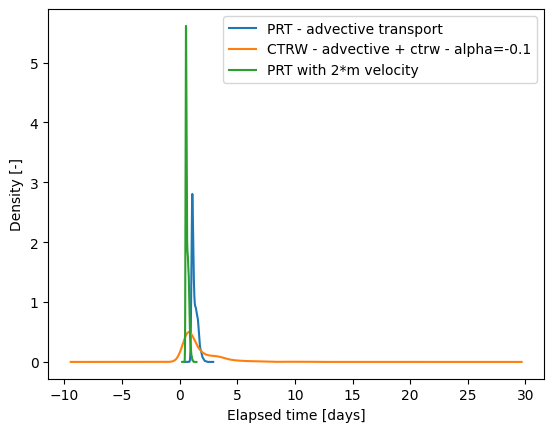

In [824]:
termination_pts.elapsed_time_prt.plot(kind='kde', label='PRT - advective transport')
termination_pts.elapsed_time_ctrw.plot(kind='kde', label=f'CTRW - advective + ctrw - alpha={alpha}')
termination_pts.elapsed_time_prtx2.plot(kind='kde', label=f'PRT with 2*m velocity')

plt.xlabel('Elapsed time [days]')
plt.ylabel('Density [-]')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Breakthrough Curve - porosity=0.0004457368')

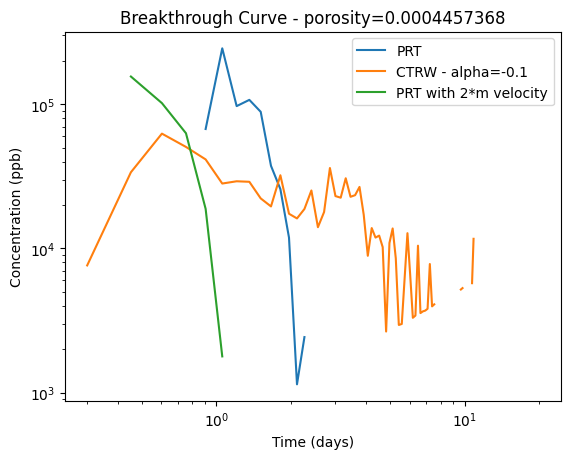

In [826]:
termination_pts['mean_v_prt'] = 93/termination_pts['elapsed_time_prt'] #93 m is the distance between the injection point and the well, which is the same for all particles, so we can compute an average velocity for each particle by dividing this distance by the elapsed time. This is a simplification, but it allows us to estimate the flow rate for each particle based on its travel time.
termination_pts['Q_prt'] = termination_pts['mean_v_prt'] * porosity*1.e-4 * 0.61 #(assuming a cell area of 0.61 m^2, 2ftx1m cell size of the model) 

termination_pts['mean_v_ctrw'] = 93/termination_pts['elapsed_time_ctrw']
termination_pts['Q_ctrw'] = termination_pts['mean_v_ctrw'] * porosity*1.e-4 * 0.61

termination_pts['mean_v_prtx2'] = 93/termination_pts['elapsed_time_prtx2']
termination_pts['Q_prtx2'] = termination_pts['mean_v_prtx2'] * porosity*1.e-4 * 0.61


n_bins = 200
tracking_days = 30
time_bins = np.linspace(0, tracking_days, n_bins)

arrivals_prt, _ = np.histogram(termination_pts['elapsed_time_prt'], bins=time_bins)
arrivals_ctrw, _ = np.histogram(termination_pts['elapsed_time_ctrw'], bins=time_bins)
arrivals_prtx2, _ = np.histogram(termination_pts['elapsed_time_prtx2'], bins=time_bins)

mass_prt = (arrivals_prt / len(termination_pts)) * 2024 #2024 mg
mass_ctrw = (arrivals_ctrw / len(termination_pts)) * 2024 #2024 mg
mass_prtx2 = (arrivals_prtx2 / len(termination_pts)) * 2024 #2024 mg

bin_width = tracking_days/n_bins

mean_flow_per_bin_prt, _ = np.histogram(termination_pts['elapsed_time_prt'], bins=time_bins, weights=termination_pts['Q_prt'])
mean_flow_per_bin_ctrw, _ = np.histogram(termination_pts['elapsed_time_ctrw'], bins=time_bins, weights=termination_pts['Q_ctrw'])
mean_flow_per_bin_prtx2, _ = np.histogram(termination_pts['elapsed_time_prtx2'], bins=time_bins, weights=termination_pts['Q_prtx2'])

count_per_bin_prt, _ = np.histogram(termination_pts['elapsed_time_prt'], bins=time_bins)
count_per_bin_ctrw, _ = np.histogram(termination_pts['elapsed_time_ctrw'], bins=time_bins)
count_per_bin_prtx2, _ = np.histogram(termination_pts['elapsed_time_prtx2'], bins=time_bins)

mean_flow_prt = mean_flow_per_bin_prt / count_per_bin_prt
mean_flow_ctrw = mean_flow_per_bin_ctrw / count_per_bin_ctrw
mean_flow_prtx2 = mean_flow_per_bin_prtx2 / count_per_bin_prtx2

conc_ppb_prt = (mass_prt * 1.e+3) / (mean_flow_prt * bin_width * 1.e+3)
conc_ppb_ctrw = (mass_ctrw * 1.e+3) / (mean_flow_ctrw * bin_width * 1.e+3)
conc_ppb_prtx2 = (mass_prtx2 * 1.e+3) / (mean_flow_prtx2 * bin_width * 1.e+3)
plt.plot(time_bins[:-1], conc_ppb_prt, label='PRT')
plt.plot(time_bins[:-1], conc_ppb_ctrw, label=f'CTRW - alpha={alpha}')
plt.plot(time_bins[:-1], conc_ppb_prtx2, label=f'PRT with 2*m velocity')

plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time (days)")
plt.ylabel("Concentration (ppb)")
plt.title(f"Breakthrough Curve - porosity={porosity*1.E-4}")

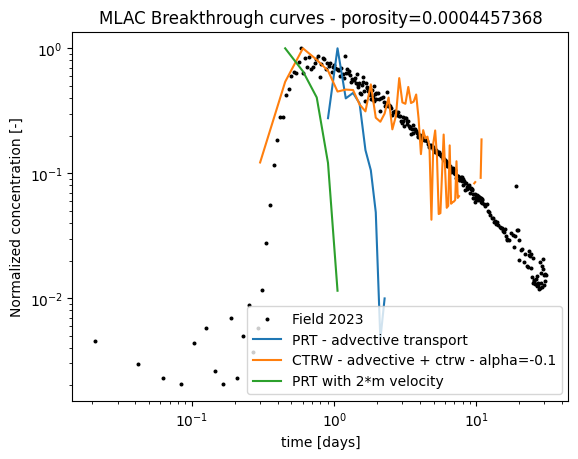

In [828]:
data_22 = pd.read_csv('../data/field_BTCs/results_MLAC2022.csv')
data_23 = pd.read_csv('../data/field_BTCs/results_MLAC2023.csv')
data_24 = pd.read_csv('../data/field_BTCs/2024_BTC.csv')
#plt.scatter(data_22['time']/24, data_22['cnc_uranine']/data_22['cnc_uranine'].max(), label='Field 2022', color='red', s=3.5)
plt.scatter(data_23['time']/24, data_23['cnc_uranine']/data_23['cnc_uranine'].max(), label='Field 2023', color='k',  s=3.5)
#plt.scatter(data_24['time (day)'], data_24[' concentration (ppb) ']/data_24[' concentration (ppb) '].max(), label='Field 2024', color='green', s=3.5)
#plt.plot(x, y, linestyle='--', color='k', linewidth=1.5)
#plt.plot(x2, y2, linestyle='--', color='red', linewidth=1.5)
#plt.plot(x3, y3, linestyle='--', color='green', linewidth=1.5)

plt.plot(time_bins[:-1], conc_ppb_prt/np.nanmax(conc_ppb_prt), label=f'PRT - advective transport')
plt.plot(time_bins[:-1], conc_ppb_ctrw/np.nanmax(conc_ppb_ctrw), label=f'CTRW - advective + ctrw - alpha={alpha}')
plt.plot(time_bins[:-1], conc_ppb_prtx2/np.nanmax(conc_ppb_prtx2), label=f'PRT with 2*m velocity')
'''ctrw_btc_df = pd.DataFrame({
    'time': time_bins[:-1],
    'conc_prt': conc_ppb_prt,
    'conc_ctrw_alpha-065': conc_ppb_ctrw
})'''
plt.xlabel('time [days]')
plt.ylabel('Normalized concentration [-]')
plt.title(f'MLAC Breakthrough curves - porosity={porosity*1.E-4}')
plt.xscale('log')
plt.yscale('log')
plt.legend()
#plt.text(1.8, 0.11, '1.10', color='red')
#plt.text(7.7, 0.44, '1.29', color='k')
#plt.text(0.49, 0.44, '1.27', color='green')
#plt.ylim(0.015, 1.6)
#plt.xlim(0.1, 40)
plt.show()

In [781]:
alpha

-0.6

In [644]:
ctrw_btc_df['conc_ctrw_x1=2m_alpha-075'] = conc_ppb_ctrw
ctrw_btc_df.head()

,time,conc_prt,conc_ctrw_alpha-065,conc_ctrw_alpha-099,conc_ctrw_alpha-085,conc_ctrw_alpha-075,conc_ctrw_x1-std1_alpha-075,conc_ctrw_x1-std1_alpha-099,conc_ctrw_x1-std1_alpha-095,conc_ctrw_x1=2m_alpha-075
0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.150754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.301508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8838.031604
3,0.452261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53085.932387
4,0.603015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67980.144637


In [545]:
np.nanmax(ctrw_btc_df['conc_ctrw_x1-std1_alpha-095'])

np.float64(nan)

In [ ]:
#std = 1
#print(f"peak concentration time for alpha = -0.95: {ctrw_btc_df[ctrw_btc_df['conc_ctrw_x1-std1_alpha-095'] == np.nanmax(ctrw_btc_df['conc_ctrw_x1-std1_alpha-095'])]['time'].values[0]}")
print(f"peak concentration time for alpha = -0.85: {ctrw_btc_df[ctrw_btc_df['conc_ctrw_x1-std1_alpha-085'] == np.nanmax(ctrw_btc_df['conc_ctrw_x1-std1_alpha-085'])]['time'].values[0]}")
print(f"peak concentration time for alpha = -0.75: {ctrw_btc_df[ctrw_btc_df['conc_ctrw_x1-std1_alpha-075'] == np.nanmax(ctrw_btc_df['conc_ctrw_x1-std1_alpha-075'])]['time'].values[0]}")
print(f"peak concentration time for alpha = -0.65: {ctrw_btc_df[ctrw_btc_df['conc_ctrw_x1-std1_alpha-065'] == np.nanmax(ctrw_btc_df['conc_ctrw_x1-std1_alpha-065'])]['time'].values[0]}")

IndexError: index 0 is out of bounds for axis 0 with size 0

mean

In [34]:
import numpy as np
from scipy.optimize import brentq

def x0_from_mean(alpha, x1, mu):
    #mean equation for truncated power law
    def mean_equation(x0):
        num = x1**(alpha+2) - x0**(alpha+2)
        den = x1**(alpha+1) - x0**(alpha+1)
        return (alpha+1)/(alpha+2) * num/den - mu

    #x0 must be in (0, x1)
    return brentq(mean_equation, 1e-12, x1*(1-1e-12))


def sample_tpl_mean(alpha, x1, mu, y=None):
    x1 = mu*1.4
    #x0 = x0_from_mean(alpha, x1, mu)
    x0 = mu*0.36

    if y is None:
        y = np.random.rand()
    x = ((x1**(alpha+1) - x0**(alpha+1))*y + x0**(alpha+1))**(1/(alpha+1))
    return x


In [1]:
m

NameError: name 'm' is not defined

In [25]:
import numpy as np

mu = 100
alpha = 1.2

x1 = mu*1.4

print(f"for alpha={alpha}, and x1={x1}, the valid m range is: ({x1*2**(-(1/(alpha+1)))}, {x1})")
print(f"you insert m={mu}")

#x0 = (2*m**(alpha+1) - x1**(alpha+1))**(1/(alpha+1))
#x1 = 1

#np.random.seed(123)
y = np.random.uniform(size=100000)

x = sample_tpl_mean(alpha, x1, mu, y)

summary = {
    "Min": np.min(x),
    #"1st Qu.": np.percentile(x, 25),
    "Median": np.median(x),
    "Mean": np.mean(x),
    #"3rd Qu.": np.percentile(x, 75),
    "Max": np.max(x)
}

example_min = summary["Min"]
example_mean = summary["Mean"]
example_median = summary["Median"]
example_max = summary["Max"]


print(f'Min = {summary["Min"]}')

print(f'Mean = {summary["Mean"]}')
print(f'Median = {summary["Median"]}')
print(f'Max = {summary["Max"]}')


for alpha=1.2, and x1=140.0, the valid m range is: (102.16360739770123, 140.0)
you insert m=100
Min = 35.78922327354556
Mean = 99.95618293175764
Median = 104.32238350099857
Max = 139.9999742868161


In [ ]:
porosity

In [56]:
#p_ctrw = pathlines.copy()

alpha = 1.2
x1 = 1222

pathlines_ctrw = pd.DataFrame() #empty dataframe to store the CTRW pathlines

for p in pathlines['irpt'].unique():
    if p % 10 == 0:
        p_ctrw = pathlines[pathlines["irpt"] == p].copy()

        p_ctrw['p_index'] = range(0, len(p_ctrw))
        for i in range(len(p_ctrw)-1):
            if i == 0: 
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_S'] = 0
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_prt'] = 0
                p_ctrw.loc[p_ctrw['p_index'] == i, 'v_prt'] = 0
                p_ctrw.loc[p_ctrw['p_index'] == i, 'v_ctrw'] = 0
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_ctrw'] = 0
                p_ctrw.loc[p_ctrw['p_index'] == i, 't_ctrw'] = p_ctrw.loc[p_ctrw['p_index'] == i, 't'].values
            else:
                #computing delta_S
                coords_i_minus_1 = p_ctrw.loc[p_ctrw['p_index'] == i-1, ["x", "y", "z"]].values
                coords_i = p_ctrw.loc[p_ctrw['p_index'] == i, ["x", "y", "z"]].values
                dist_i = np.linalg.norm(coords_i - coords_i_minus_1)
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_S'] = dist_i
                
                #delta_t_prt
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_prt'] = p_ctrw.loc[p_ctrw['p_index'] == i, 't'].values - p_ctrw.loc[p_ctrw['p_index'] == i-1, 't'].values
                
                #v_prt
                p_ctrw.loc[p_ctrw['p_index'] == i, 'v_prt'] = p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_S'].values / p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_prt'].values
                
                #getting v_prt (m) to sample v_ctrw
                m = p_ctrw.loc[p_ctrw['p_index'] == i, 'v_prt'].values
                p_ctrw.loc[p_ctrw['p_index'] == i, 'v_ctrw'] = sample_tpl(alpha, x1, m) #CHANGE MEDIAN OR MEAN

                #delta_t_ctrw
                p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_ctrw'] = p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_S'].values / p_ctrw.loc[p_ctrw['p_index'] == i, 'v_ctrw'].values
                
                #t_ctrw
                p_ctrw.loc[p_ctrw['p_index'] == i, 't_ctrw'] = p_ctrw.loc[p_ctrw['p_index'] == i-1, 't_ctrw'].values + p_ctrw.loc[p_ctrw['p_index'] == i, 'delta_t_ctrw'].values
        pathlines_ctrw = pd.concat([pathlines_ctrw, p_ctrw], ignore_index=True)
    else: 
        continue

In [57]:
len(pathlines_ctrw)

138865

In [58]:
pathlines_ctrw.head()

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,...,y,z,name,p_index,delta_S,delta_t_prt,v_prt,v_ctrw,delta_t_ctrw,t_ctrw
0,1,1,2,1,10,2,199996,0,1,0,...,6888.518460,-4.572000,NaN,0,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000
1,2,1,2,1,10,2,199996,0,1,1,...,6888.513460,-4.571993,NaN,1,0.005703,0.000002,3150.022778,3470.208171,0.000002,14.000002
2,2,1,2,1,10,2,200384,0,1,1,...,6887.950395,-4.571829,NaN,2,0.570573,0.000236,2413.650883,2923.617378,0.000195,14.000197
3,2,1,2,1,10,2,200383,0,1,1,...,6887.513460,-4.571647,NaN,3,0.487781,0.000480,1017.261588,986.023757,0.000495,14.000691
4,2,1,2,1,10,2,200771,0,1,1,...,6886.513460,-4.571925,NaN,4,1.009440,0.001188,849.783430,875.394098,0.001153,14.001845


In [53]:
pathlines_ctrw.to_csv(os.path.join(model_ws, f"{prt_name}_ctrw_pathlines_median.csv"), index=False)

In [6]:
pathlines_ctrw = pd.read_csv(os.path.join(model_ws, f"{prt_name}_ctrw_pathlines_median.csv"))

C:\Users\lima0055\AppData\Local\Temp\ipykernel_12608\2361656733.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


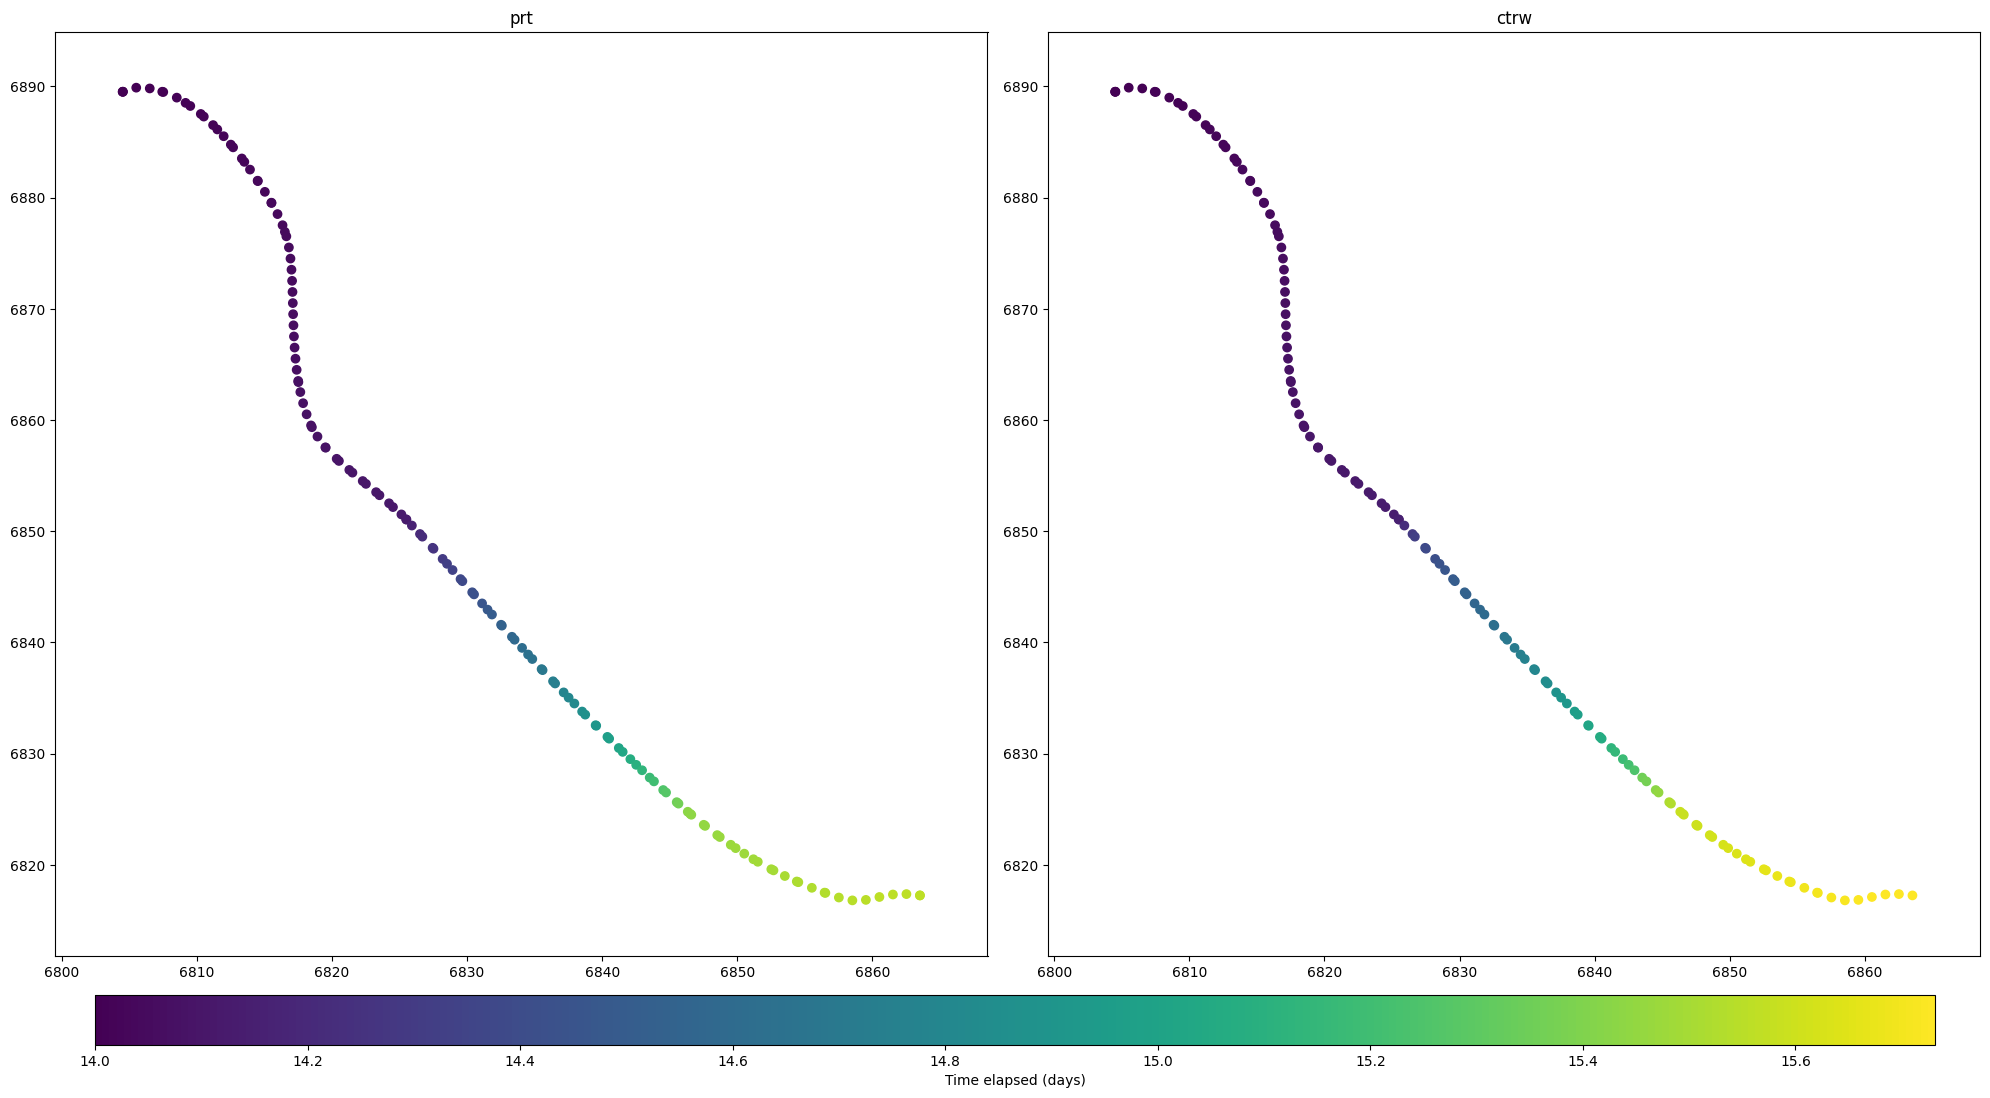

In [43]:
import matplotlib.pyplot as plt

import matplotlib.colors as colors
import flopy

fig = plt.figure(figsize=(20, 10)) # Increased width for two plots

t_combined = np.concatenate([p_ctrw["t"].values, p_ctrw["t_ctrw"].values])[:-1]
vmin, vmax = t_combined.min(), t_combined.max()

norm = colors.Normalize(vmin=vmin, vmax=vmax)

ax1 = fig.add_subplot(1, 2, 1)
modelmap1 = flopy.plot.PlotMapView(model=gwf, ax=ax1)
modelmap1.plot_grid()

sc1 = ax1.scatter(p_ctrw["x"], p_ctrw["y"], c=p_ctrw["t"], cmap="viridis", norm=norm)
#plt.colorbar(sc1, ax=ax1, label="Time elapsed (days)")

ax1.set_title("prt")
ax1.set_xlim(p_ctrw['x'].min() - 5, p_ctrw['x'].max() + 5)
ax1.set_ylim(p_ctrw['y'].min() - 5, p_ctrw['y'].max() + 5)

ax2 = fig.add_subplot(1, 2, 2)
modelmap2 = flopy.plot.PlotMapView(model=gwf, ax=ax2)
modelmap2.plot_grid()

sc2 = ax2.scatter(p_ctrw["x"], p_ctrw["y"], c=p_ctrw["t_ctrw"], cmap="viridis", norm=norm) 
#plt.colorbar(sc2, ax=[ax1, ax2], label="Time elapsed (days)", orientation='horizontal')
#cbar = fig.colorbar(sc1, ax=[ax1, ax2], orientation='horizontal', pad=0.1)


cbar_ax = fig.add_axes([0.05, -0.05, 0.92, 0.05]) 
cbar = fig.colorbar(sc1, ax=[ax1, ax2], orientation='horizontal', pad=0.1, cax=cbar_ax)
cbar.set_label("Time elapsed (days)")

ax2.set_title("ctrw")
ax2.set_xlim(p_ctrw['x'].min() - 5, p_ctrw['x'].max() + 5)
ax2.set_ylim(p_ctrw['y'].min() - 5, p_ctrw['y'].max() + 5)

plt.tight_layout()
plt.show()


(6833.0, 6836.0)

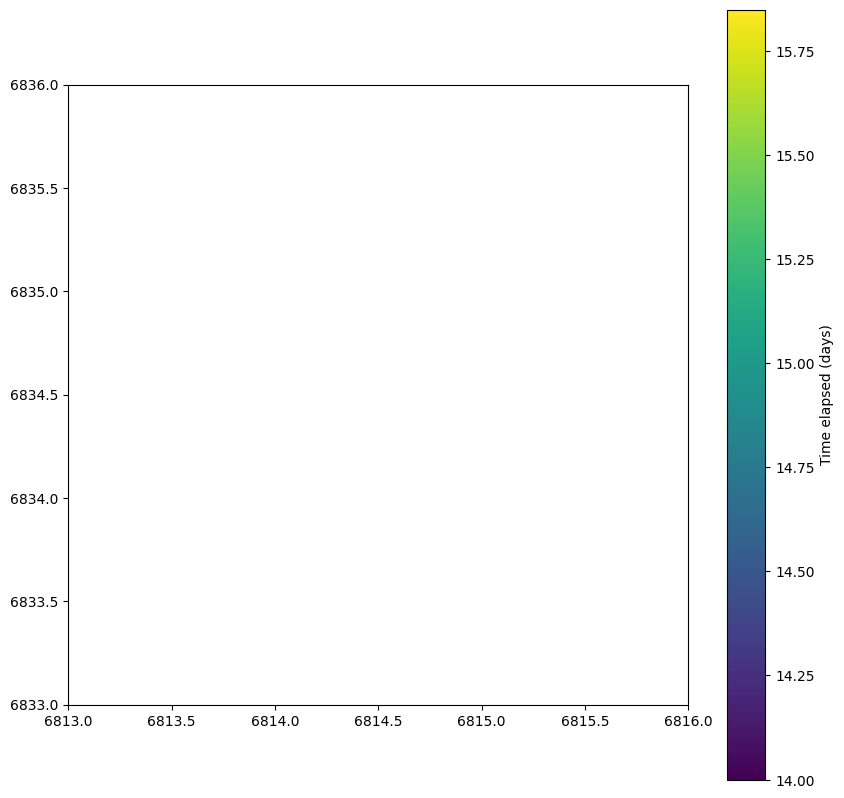

In [40]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, aspect="equal")
modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax)
modelmap.plot_grid()
plt.scatter(p_ctrw["x"].values, p_ctrw["y"].values, c=p_ctrw["t_ctrw"].values, cmap="viridis", label="Particle pathlines")
plt.colorbar(label="Time elapsed (days)")
#plt.xlim(p['x'].min()-5, p['x'].min()+5)
#plt.ylim(p['y'].max()-10, p['y'].max()+1)


plt.xlim(6813, 6816)
plt.ylim(6833, 6836)

In [59]:
pathlines_ctrw.loc[pathlines_ctrw['irpt'] == 10, 't_ctrw']

0      14.000000
1      14.000002
2      14.000197
3      14.000691
4      14.001845
         ...    
132    15.178996
133    15.179021
134    15.179552
135    15.179738
136          NaN
Name: t_ctrw, Length: 137, dtype: float64

In [60]:
for p in pathlines_ctrw['irpt'].unique():
    mask = pathlines_ctrw['irpt'] == p
    group_indices = pathlines_ctrw[mask].index

    if len(group_indices) >= 2:
        last_idx = group_indices[-1]
        second_last_idx = group_indices[-2]
        pathlines_ctrw.loc[last_idx, 't_ctrw'] = pathlines_ctrw.loc[second_last_idx, 't_ctrw']


pathlines_ctrw.loc[pathlines_ctrw['irpt'] == 10, :]

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,...,y,z,name,p_index,delta_S,delta_t_prt,v_prt,v_ctrw,delta_t_ctrw,t_ctrw
0,1,1,2,1,10,2,199996,0,1,0,...,6888.518460,-4.572000,NaN,0,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000
1,2,1,2,1,10,2,199996,0,1,1,...,6888.513460,-4.571993,NaN,1,0.005703,0.000002,3150.022778,3470.208171,0.000002,14.000002
2,2,1,2,1,10,2,200384,0,1,1,...,6887.950395,-4.571829,NaN,2,0.570573,0.000236,2413.650883,2923.617378,0.000195,14.000197
3,2,1,2,1,10,2,200383,0,1,1,...,6887.513460,-4.571647,NaN,3,0.487781,0.000480,1017.261588,986.023757,0.000495,14.000691
4,2,1,2,1,10,2,200771,0,1,1,...,6886.513460,-4.571925,NaN,4,1.009440,0.001188,849.783430,875.394098,0.001153,14.001845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,2,1,2,1,10,2,233405,0,1,1,...,6802.551615,-4.568962,NaN,132,1.062108,0.001061,1000.816087,1018.152223,0.001043,15.178996
133,2,1,2,1,10,2,233406,0,1,1,...,6802.513460,-4.568607,NaN,133,0.039583,0.000030,1301.941747,1565.672170,0.000025,15.179021
134,2,1,2,1,10,2,233794,0,1,1,...,6801.513460,-4.559330,NaN,134,1.032563,0.000534,1935.043833,1947.692267,0.000530,15.179552
135,2,1,2,1,10,2,234182,0,1,1,...,6800.513460,-4.552772,NaN,135,1.010483,0.000230,4395.596009,5434.609816,0.000186,15.179738


In [61]:
termination_pts = pathlines_ctrw[pathlines_ctrw.ireason == 3].set_index('irpt')

termination_pts['elapsed_time_prt'] = termination_pts.t - termination_pts.trelease
termination_pts['elapsed_time_ctrw'] = termination_pts.t_ctrw - termination_pts.trelease

In [62]:
termination_pts.head()

,kper,kstp,imdl,iprp,ilay,icell,izone,istatus,ireason,trelease,...,name,p_index,delta_S,delta_t_prt,v_prt,v_ctrw,delta_t_ctrw,t_ctrw,elapsed_time_prt,elapsed_time_ctrw
irpt,,,,,,,,,,,,,,,,,,,,,
10,2,1,2,1,2,234570,0,5,3,14.0,...,NaN,136,NaN,NaN,NaN,NaN,NaN,15.179738,1.051015,1.179738
20,2,1,2,1,2,234570,0,5,3,14.0,...,NaN,134,NaN,NaN,NaN,NaN,NaN,15.243585,1.048921,1.243585
30,2,1,2,1,2,234570,0,5,3,14.0,...,NaN,134,NaN,NaN,NaN,NaN,NaN,15.118316,1.052152,1.118316
40,2,1,2,1,2,234570,0,5,3,14.0,...,NaN,134,NaN,NaN,NaN,NaN,NaN,15.318748,1.058944,1.318748
50,2,1,2,1,2,234570,0,5,3,14.0,...,NaN,136,NaN,NaN,NaN,NaN,NaN,15.254057,1.070575,1.254057


In [63]:
len(termination_pts)

1000

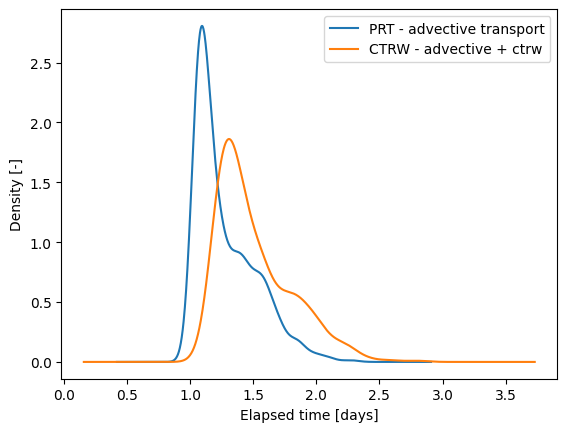

In [64]:
termination_pts.elapsed_time_prt.plot(kind='kde', label='PRT - advective transport')
termination_pts.elapsed_time_ctrw.plot(kind='kde', label='CTRW - advective + ctrw')

plt.xlabel('Elapsed time [days]')
plt.ylabel('Density [-]')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Breakthrough Curve - porosity=0.0004457368')

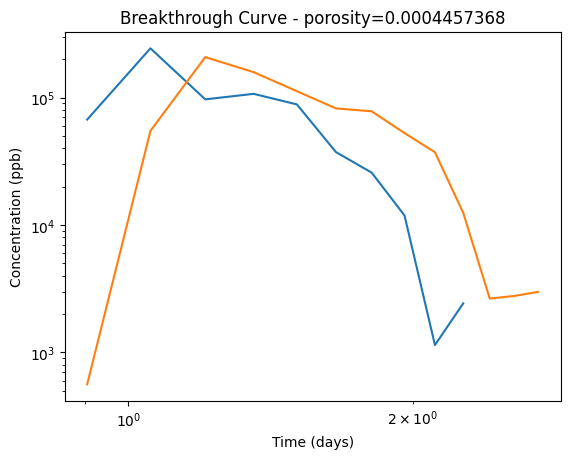

In [65]:
termination_pts['mean_v_prt'] = 93/termination_pts['elapsed_time_prt']
termination_pts['Q_prt'] = termination_pts['mean_v_prt'] * porosity*1.e-4 * 0.61 #(assuming a cell area of 0.61 m^2, 2ftx1m cell size of the model) 

termination_pts['mean_v_ctrw'] = 93/termination_pts['elapsed_time_ctrw']
termination_pts['Q_ctrw'] = termination_pts['mean_v_ctrw'] * porosity*1.e-4 * 0.61


n_bins = 200
tracking_days = 30
time_bins = np.linspace(0, tracking_days, n_bins)
arrivals_prt, _ = np.histogram(termination_pts['elapsed_time_prt'], bins=time_bins)
arrivals_ctrw, _ = np.histogram(termination_pts['elapsed_time_ctrw'], bins=time_bins)
mass_prt = (arrivals_prt / len(termination_pts)) * 2024 #2024 mg
mass_ctrw = (arrivals_ctrw / len(termination_pts)) * 2024 #2024 mg

bin_width = tracking_days/n_bins

mean_flow_per_bin_prt, _ = np.histogram(termination_pts['elapsed_time_prt'], bins=time_bins, weights=termination_pts['Q_prt'])
mean_flow_per_bin_ctrw, _ = np.histogram(termination_pts['elapsed_time_ctrw'], bins=time_bins, weights=termination_pts['Q_ctrw'])
count_per_bin_prt, _ = np.histogram(termination_pts['elapsed_time_prt'], bins=time_bins)
count_per_bin_ctrw, _ = np.histogram(termination_pts['elapsed_time_ctrw'], bins=time_bins)
mean_flow_prt = mean_flow_per_bin_prt / count_per_bin_prt
mean_flow_ctrw = mean_flow_per_bin_ctrw / count_per_bin_ctrw

conc_ppb_prt = (mass_prt * 1.e+3) / (mean_flow_prt * bin_width * 1.e+3)
conc_ppb_ctrw = (mass_ctrw * 1.e+3) / (mean_flow_ctrw * bin_width * 1.e+3)
plt.plot(time_bins[:-1], conc_ppb_prt, label='PRT')
plt.plot(time_bins[:-1], conc_ppb_ctrw, label='CTRW')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time (days)")
plt.ylabel("Concentration (ppb)")
plt.title(f"Breakthrough Curve - porosity={porosity*1.E-4}")

In [15]:
data_22 = pd.read_csv('../data/field_BTCs/results_MLAC2022.csv')
data_23 = pd.read_csv('../data/field_BTCs/results_MLAC2023.csv')
data_24 = pd.read_csv('../data/field_BTCs/2024_BTC.csv')

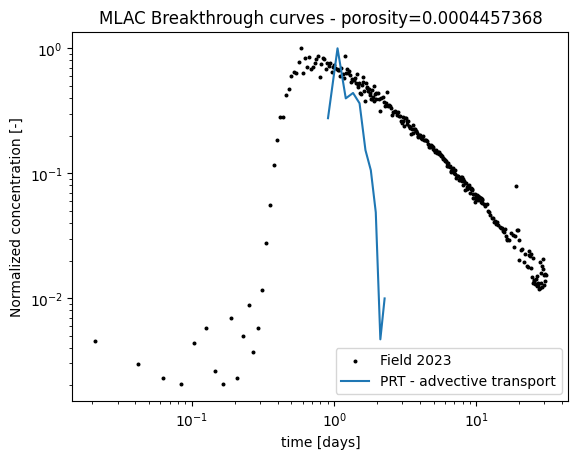

In [ ]:
data_22 = pd.read_csv('../data/field_BTCs/results_MLAC2022.csv')
data_23 = pd.read_csv('../data/field_BTCs/results_MLAC2023.csv')
data_24 = pd.read_csv('../data/field_BTCs/2024_BTC.csv')
#plt.scatter(data_22['time']/24, data_22['cnc_uranine']/data_22['cnc_uranine'].max(), label='Field 2022', color='red', s=3.5)
plt.scatter(data_23['time']/24, data_23['cnc_uranine']/data_23['cnc_uranine'].max(), label='Field 2023', color='k',  s=3.5)
#plt.scatter(data_24['time (day)'], data_24[' concentration (ppb) ']/data_24[' concentration (ppb) '].max(), label='Field 2024', color='green', s=3.5)
#plt.plot(x, y, linestyle='--', color='k', linewidth=1.5)
#plt.plot(x2, y2, linestyle='--', color='red', linewidth=1.5)
#plt.plot(x3, y3, linestyle='--', color='green', linewidth=1.5)

plt.plot(time_bins[:-1], conc_ppb_prt/np.nanmax(conc_ppb_prt), label=f'PRT - advective transport')
#plt.plot(time_bins[:-1], conc_ppb_ctrw/np.nanmax(conc_ppb_ctrw), label=f'CTRW - advective + ctrw - alpha={alpha}')

plt.xlabel('time [days]')
plt.ylabel('Normalized concentration [-]')
plt.title(f'MLAC Breakthrough curves - porosity={porosity*1.E-4}')
plt.xscale('log')
plt.yscale('log')
plt.legend()
#plt.text(1.8, 0.11, '1.10', color='red')
#plt.text(7.7, 0.44, '1.29', color='k')
#plt.text(0.49, 0.44, '1.27', color='green')
#plt.ylim(0.015, 1.6)
#plt.xlim(0.1, 40)
plt.show()